# Laboratorium: Spadek Gradientowy (Gradient Descent) od zera

Twoim zadaniem będzie zaprogramowanie od podstaw algorytmu optymalizacji, który stanowi absolutny fundament uczenia współczesnych modeli Sztucznej Inteligencji (w tym głębokich sieci neuronowych) – **Spadku Gradientowego**.

Na wykładzie poznałeś pojęcia **powierzchni w przestrzeni $\mathbb{R}^n$**, **map poziomic** oraz **pochodnych cząstkowych**, z których budujemy wektor **gradientu**. Dziś ożywimy tę teorię.

### Twój cel na dziś:
1. Zdefiniować w Pythonie matematyczny "krajobraz" – czyli funkcję straty $f(x,y)$, która symuluje błąd naszego modelu.
2. Analitycznie (na kartce) wyliczyć pochodne cząstkowe $\frac{\partial f}{\partial x}$ oraz $\frac{\partial f}{\partial y}$ i wpisać je do kodu.
3. Napisać pętlę uczącą, która krok po kroku aktualizuje pozycję punktu startowego, zjeżdżając na dno doliny w kierunku wskazywanym przez *ujemny gradient*.
4. Zwizualizować całą trasę algorytmu na mapie poziomic.

### Krok 1: Definicja środowiska i funkcji
Abyśmy w późniejszych etapach zajęć mogli łatwo psuć modele (np. wrzucając je do zdradliwych "wąskich dolin" wywołujących zygzakowanie), wydzielimy definicję samej funkcji i jej gradientu w jednym, łatwo edytowalnym miejscu.

Zaczniemy od najprostszego, idealnego przypadku – symetrycznej "miski":
$$f(x,y) = x^2 + y^2$$

Uruchom poniższą komórkę, upewniając się, że rozumiesz strukturę przygotowanych funkcji.

### Krok 1: Definicja środowiska i funkcji (ZADANIE)

Zaczniemy od najprostszego, idealnego przypadku – symetrycznej "miski", wyrażonej wzorem:
$$f(x,y) = x^2 + y^2$$

**Co musisz zrobić w poniższej komórce z kodem:**
1. **Zaimplementuj funkcję `f(x, y)`:** Ma ona po prostu zwracać wartość powyższego równania dla zadanych argumentów `x` i `y`.
2. **Wylicz pochodne na kartce:** Oblicz pochodną cząstkową po $x$ (traktując $y$ jako stałą) oraz po $y$ (traktując $x$ jako stałą).
3. **Zaimplementuj funkcję `gradient(x, y)`:** Przenieś swoje obliczenia z kartki do Pythona. Funkcja musi zwracać wyliczone pochodne w formie wektora (użyj do tego struktury `np.array([pochodna_x, pochodna_y])`).

Gdy uzupełnisz kod, uruchom komórkę. Na dole znajduje się krótki test, który sprawdzi, czy Twoje wzory zwracają poprawne wyniki dla punktu `(1.0, 2.0)`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# KROK 1: ZDEFINIUJ FUNKCJĘ I JEJ GRADIENT (Wersja uzupełniona)
# =====================================================================

def f(x, y):
    """
    Funkcja straty (krajobraz błędu).
    Zwraca wysokość terenu (błąd) w danym punkcie (x, y).

    Wzór: f(x, y) = x^2 + y^2
    """
    # WYJAŚNIENIE: W Pythonie potęgowanie zapisujemy jako podwójną gwiazdkę (**).
    # Zwracamy po prostu sumę kwadratów obu współrzędnych.
    return 5*x**2 + y**2


def gradient(x, y):
    """
    Wektor gradientu. Zwraca kierunek NAJSZYBSZEGO WZROSTU funkcji.
    """
    # WYJAŚNIENIE MATEMATYCZNE:
    # Liczymy pochodną cząstkową po zmiennej 'x'.
    # Zgodnie z zasadami z wykładu, traktujemy wtedy 'y' jako stałą liczbę.
    # Pochodna z x^2 to 2x. Pochodna ze stałej y^2 to 0.
    # Zatem df/dx = 2x + 0 = 2x
    df_dx = 10 * x

    # Podobnie dla pochodnej po zmiennej 'y'.
    # Tym razem 'x' traktujemy jako stałą (jej pochodna to 0).
    # Pochodna z y^2 to 2y.
    # Zatem df/dy = 0 + 2y = 2y
    df_dy = 2 * y

    # WYJAŚNIENIE PROGRAMISTYCZNE:
    # Gradient to wektor, dlatego pakujemy obie pochodne do tablicy numpy (np.array).
    # Dzięki temu w kolejnych krokach (w pętli uczącej) będziemy mogli
    # wykonywać operacje matematyczne (jak odejmowanie czy mnożenie przez learning_rate)
    # na obu współrzędnych jednocześnie (wektorowo).
    return np.array([df_dx, df_dy])


# =====================================================================
# TEST POPRAWNOŚCI (Nie modyfikuj poniższego kodu)
# =====================================================================
try:
    test_x, test_y = 1.0, 2.0
    val = f(test_x, test_y)
    grad = gradient(test_x, test_y)

    print("--- WYNIKI TESTU ---")
    print(f"Wysokość w punkcie ({test_x}, {test_y}): f(x,y) = {val}")
    print(f"Gradient w punkcie ({test_x}, {test_y}): [df/dx, df/dy] = {grad}")

    # Dla x=1, y=2 funkcja powinna zwrócić 1^2 + 2^2 = 5
    # Gradient powinien wynieść [2*1, 2*2] = [2, 4]
    if val == 5.0 and np.array_equal(grad, np.array([2.0, 4.0])):
        print("\n✅ ŚWIETNIE! Funkcja i gradient zaimplementowane poprawnie. Możesz przejść dalej!")
    else:
        print("\n❌ Coś poszło nie tak. Sprawdź swoje wzory matematyczne.")
except Exception as e:
    print(f"\n⚠️ Błąd wykonania kodu. Czy na pewno uzupełniłeś wszystkie miejsca 'TODO'?\nSzczegóły błędu: {e}")

--- WYNIKI TESTU ---
Wysokość w punkcie (1.0, 2.0): f(x,y) = 9.0
Gradient w punkcie (1.0, 2.0): [df/dx, df/dy] = [10.  4.]

❌ Coś poszło nie tak. Sprawdź swoje wzory matematyczne.


### Przerwa na teorię: Jak właściwie działa Spadek Gradientowy?

Zanim narysujemy naszą trasę na mapie, zatrzymajmy się na chwilę. Równania, które przed chwilą zaprogramowałeś, opisują jeden z najbardziej eleganckich i intuicyjnych algorytmów w całej informatyce.

Wyobraź sobie, że zostałeś zrzucony helikopterem gdzieś w górach. Masz na oczach opaskę, jest gęsta mgła, a Twoim zadaniem jest jak najszybsze zejście na samo dno doliny. Nie widzisz całego krajobrazu, więc co robisz?


Zaczynasz badać grunt stopami. Sprawdzasz, w którym kierunku ziemia opada najbardziej stromo, i robisz w tamtą stronę ostrożny krok. Potem znowu badasz grunt pod stopami, znajdujesz nowy najstromszy spadek i robisz kolejny krok. Powtarzasz to tak długo, aż poczujesz, że we wszystkich kierunkach teren zaczyna się wznosić – to znak, że dotarłeś na dno.

Dokładnie to robi model sztucznej inteligencji! Przełóżmy tę analogię na pojęcia techniczne:

#### 1. Góry i doliny, czyli Funkcja Straty (Loss Function)
W sztucznej inteligencji "wysokość n.p.m." to po prostu wielkość błędu, jaki popełnia nasz model. Naszym celem jest znalezienie takiego ustawienia parametrów (współrzędnych na mapie), dla których błąd jest najmniejszy (dno doliny). Matematycznie ten krajobraz to nasza funkcja $f(x,y)$.

#### 2. Badanie gruntu stopami, czyli Gradient
Komputer nie widzi całego wykresu funkcji. Może jedynie sprawdzić "nachylenie terenu" w punkcie, w którym aktualnie stoi, wyliczając **pochodne cząstkowe**. Gradient to wektor, który działa jak kompas – wskazuje kierunek, w którym góra *wznosi się* najbardziej stromo. Skoro chcemy zejść w dół, musimy iść w kierunku **przeciwnym** do gradientu (stąd znak minus w Twojej pętli!).

#### 3. Rozmiar kroku, czyli Współczynnik Uczenia (Learning Rate)
Kiedy wiesz już, w którą stronę iść, musisz zdecydować, jak szeroki krok zrobić. W matematyce nazywa się to współczynnikiem uczenia (często oznaczanym symbolem $\alpha$). To absolutnie kluczowy parametr:

* **Zbyt mały krok:** Będziesz schodzić do doliny w nieskończoność (algorytm uczy się za wolno).
* **Zbyt duży krok:** Rozpędzisz się tak bardzo, że przeskoczysz dno doliny i wylądujesz na przeciwległym zboczu, a potem odbijesz się jeszcze wyżej (zjawisko dywergencji – algorytm "wybucha" i nigdy nie znajduje rozwiązania).

#### 4. Krok po kroku, czyli Iteracja (Epoki)
Cały ten proces to po prostu pętla `for`, w której komputer powtarza to samo równanie, aktualizując swoją pozycję, aż dotrze do celu:
$$Pozycja_{nowa} = Pozycja_{stara} - \alpha \cdot Gradient$$

### Krok 2: Pętla optymalizacji – Spadek Gradientowy (ZADANIE) ⚙️

Mamy już funkcję i wiemy, jak obliczyć jej gradient (kierunek najszybszego wzrostu). Ponieważ chcemy zminimalizować błąd (znaleźć dno doliny), musimy poruszać się w kierunku **przeciwnym** do gradientu.

Algorytm Spadku Gradientowego (Gradient Descent) to po prostu powtarzanie w pętli jednego matematycznego kroku:
$$x_{nowy} = x_{stary} - \alpha \cdot \frac{\partial f}{\partial x}$$
$$y_{nowy} = y_{stary} - \alpha \cdot \frac{\partial f}{\partial y}$$

Symbol $\alpha$ (alfa) to w żargonie AI **Współczynnik Uczenia (Learning Rate)**. Decyduje on o tym, jak duże kroki stawiamy. Zbyt mały – algorytm będzie uczył się wiekami. Zbyt duży – przeskoczymy dno i wyrzucimy model w kosmos.

**Co musisz zrobić w poniższej komórce:**
1. Uzupełnij funkcję `gradient_descent`.
2. Wewnątrz pętli `for` wywołaj swoją funkcję `gradient(x, y)`, aby dowiedzieć się, w którą stronę iść.
3. Zaktualizuj wartości `x` oraz `y` odejmując od nich gradient pomnożony przez `learning_rate`.
4. Zapisuj nowe pozycje do przygotowanych list, abyśmy mogli je później narysować!

In [14]:
# =====================================================================
# KROK 2: PĘTLA ALGORYTMU SPADKU GRADIENTOWEGO (Wersja uzupełniona)
# =====================================================================

def gradient_descent(start_x, start_y, learning_rate, epochs):
    """
    Wykonuje algorytm spadku gradientowego.

    Parametry:
    - start_x, start_y: współrzędne punktu startowego
    - learning_rate: rozmiar kroku (alfa)
    - epochs: liczba iteracji (kroków) pętli

    Zwraca:
    - history_x, history_y, history_f: listy z zapisaną trasą algorytmu
    """

    # Ustawiamy pozycję początkową
    x = start_x
    y = start_y

    # Tworzymy listy do śledzenia trasy (przydadzą się do wykresu)
    history_x = [x]
    history_y = [y]
    history_f = [f(x, y)]

    # Główna pętla ucząca modelu
    for i in range(epochs):

        # 1. Obliczamy gradient w obecnym punkcie
        # WYJAŚNIENIE: Wywołujemy naszą funkcję z Kroku 1.
        # Zwraca ona tablicę [df_dx, df_dy].
        grad = gradient(x, y)

        # 2. Aktualizujemy pozycję (ZASADA SPADKU GRADIENTOWEGO)
        # WYJAŚNIENIE: Ponieważ `grad` to wektor (np.array), możemy przemnożyć
        # obie współrzędne przez learning_rate i odjąć je w dwóch czytelnych linijkach.
        # Minus oznacza, że idziemy W DÓŁ zbocza, a nie pod górę.
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]

        # 3. Zapisujemy nową pozycję do historii
        history_x.append(x)
        history_y.append(y)
        history_f.append(f(x, y))

    return history_x, history_y, history_f

# =====================================================================
# TEST PĘTLI
# =====================================================================
# Zrzucamy naszą "kulkę" na pozycję x=4, y=4.
# Ustawiamy learning_rate na 0.1 i pozwalamy jej wykonać 20 kroków.
hx, hy, hf = gradient_descent(start_x=4.0, start_y=4.0, learning_rate=0.1, epochs=20)

print(f"Pozycja startowa: x={hx[0]:.4f}, y={hy[0]:.4f}, błąd={hf[0]:.4f}")
print(f"Pozycja końcowa:  x={hx[-1]:.4f}, y={hy[-1]:.4f}, błąd={hf[-1]:.4f}")

# Dno naszej miski x^2 + y^2 znajduje się w punkcie (0,0).
# Jeśli algorytm zadziałał, pozycja końcowa powinna być bardzo bliska zeru!
if abs(hx[-1]) < 0.1 and abs(hy[-1]) < 0.1:
    print("\n✅ SUKCES! Algorytm zjechał na dno doliny. Jesteśmy gotowi na rysowanie!")
else:
    print("\n❌ Coś nie gra. Kula nie dotarła na dno. Sprawdź wzór aktualizacji pozycji.")

Pozycja startowa: x=4.0000, y=4.0000, błąd=96.0000
Pozycja końcowa:  x=0.0000, y=0.0461, błąd=0.0021

✅ SUKCES! Algorytm zjechał na dno doliny. Jesteśmy gotowi na rysowanie!


### Krok 3: Ożywiamy matematykę – Wizualizacja na mapie poziomic

Nasz algorytm działa w tle, wyliczając zera i jedynki. Ale w Sztucznej Inteligencji równie ważne co wyliczenie wyniku, jest zrozumienie, *jak* model do niego dotarł.

Teraz wykorzystamy bibliotekę `matplotlib`, aby narysować płaską mapę naszego trójwymiarowego krajobrazu (mapę poziomic / warstwic). Następnie nałożymy na nią czerwoną ścieżkę, po której zjeżdżała nasza wirtualna kulka, opierając się na listach `history_x` oraz `history_y`.

**Co musisz zrobić w poniższej komórce:**
1. Użyj funkcji `np.meshgrid`, aby stworzyć siatkę współrzędnych (nasze płótno).
2. Oblicz wartości funkcji `Z = f(X, Y)` dla całej siatki.
3. Narysuj mapę poziomic używając `plt.contourf()`.
4. Narysuj trasę algorytmu używając `plt.plot()`, przekazując mu listy z historią pozycji z poprzedniego kroku.

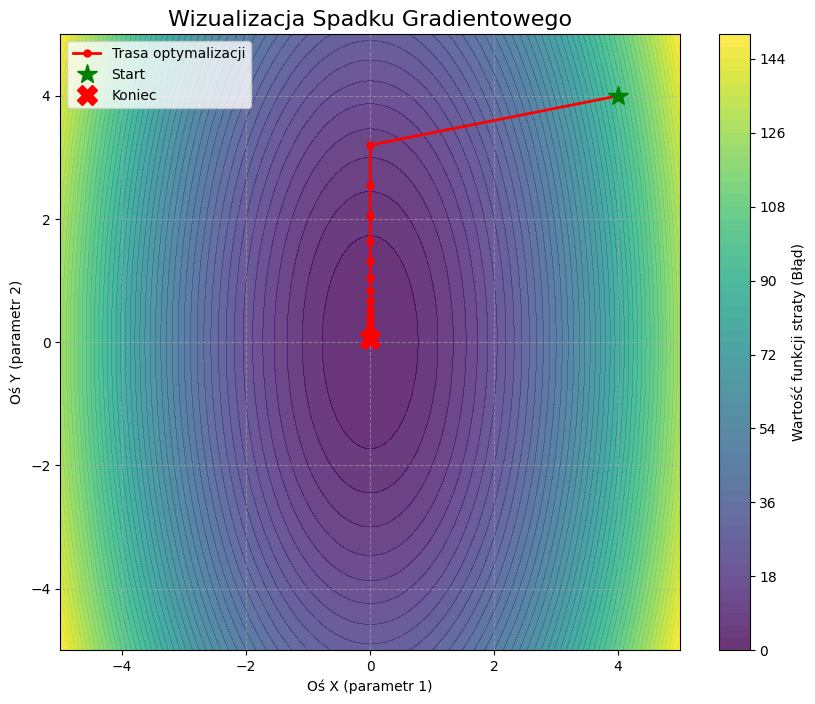

In [15]:
# =====================================================================
# KROK 3: WIZUALIZACJA TRASY ALGORYTMU (Wersja uzupełniona)
# =====================================================================

# 1. PRZYGOTOWANIE MAPY (Siatka X i Y)
# Tworzymy 100 punktów od -5 do 5 na obu osiach
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)

# Używamy meshgrid, aby stworzyć siatkę 2D (płótno do rysowania)
X, Y = np.meshgrid(x_range, y_range)

# 2. OBLICZENIE WYSOKOŚCI TERENU
# Dla każdego punktu na siatce wyliczamy jego wysokość z naszej funkcji f(x,y)
Z = f(X, Y)

# 3. RYSOWANIE WYKRESU
plt.figure(figsize=(10, 8))

# Rysujemy kolorową mapę poziomic (contourf - 'f' od filled)
# WYJAŚNIENIE: levels=50 oznacza gęstość warstwic, cmap='viridis' to popularna, czytelna paleta kolorów
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(label='Wartość funkcji straty (Błąd)')

# Nanosimy trasę naszego algorytmu!
# WYJAŚNIENIE: hx i hy to listy pozycji wyliczone w poprzedniej komórce (Krok 2)
# Używamy czerwonego koloru ('r'), łączymy punkty linią ciągłą ('-') i zaznaczamy kroki kropkami ('o')
plt.plot(hx, hy, 'r-o', markersize=5, linewidth=2, label='Trasa optymalizacji')

# Zaznaczamy wyraźnie punkt startowy (zielona gwiazdka) i końcowy (czerwony X)
plt.plot(hx[0], hy[0], 'g*', markersize=15, label='Start')
plt.plot(hx[-1], hy[-1], 'rX', markersize=15, label='Koniec')

# Estetyka wykresu
plt.title('Wizualizacja Spadku Gradientowego', fontsize=16)
plt.xlabel('Oś X (parametr 1)')
plt.ylabel('Oś Y (parametr 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Wyświetlamy dzieło!
plt.show()

### Eksperyment 1: Skoki kangura, czyli za duży krok

Nasz algorytm gładko zjechał na dno doliny, ponieważ ustawiliśmy bezpieczny współczynnik uczenia (`learning_rate = 0.1`). Ale co się stanie, gdy model będzie zbyt "niecierpliwy"?

**Twoje zadanie:**
1. Wróć do komórki z kodem z **Kroku 2** (tam, gdzie wywołujesz funkcję `gradient_descent`).
2. Zmień wartość `learning_rate` z `0.1` na `0.9`.
3. Uruchom ponownie tę komórkę (`Shift + Enter`), a następnie uruchom ponownie komórkę z wykresem (**Krok 3**).

**Co tu się stało?**
Zamiast gładkiej linii powinieneś zobaczyć czerwoną "pajęczynę" przeskakującą z jednej strony tarczy na drugą. To zjawisko nazywamy **oscylacjami**. Krok był tak duży, że algorytm przeskakiwał dno doliny i lądował wysoko na przeciwległym zboczu. Ostatecznie dotarł do celu, ale zajęło mu to dużo więcej czasu i niepotrzebnego "rzucania się" na boki.

### Eksperyment 2: Katastrofa i wybuch modelu

Skoro krok `0.9` wywołał oscylacje, spróbujmy przekroczyć granicę bezpieczeństwa.

**Twoje zadanie:**
1. Wróć do komórki z **Kroku 2**.
2. Ustaw `learning_rate = 1.1`.
3. Uruchom komórkę z pętlą i komórkę z wykresem.

**Co tu się stało?**
Twój wykres prawdopodobnie zniknął lub jest całkowicie zepsuty, a w Pythonie mogły pojawić się błędy! Dlaczego? Algorytm odbijał się od ścian doliny z taką siłą, że z każdym krokiem lądował *wyżej* niż poprzednio. Wartości rosły w nieskończoność, aż komputer nie był w stanie ich zapisać (przepełnienie, zjawisko ucieczki/dywergencji). Właśnie zniszczyłeś proces uczenia modelu!

### Eksperyment 3: Złe uwarunkowanie ("Wąska dolina")

W prawdziwych projektach AI (np. przy głębokich sieciach neuronowych) krajobraz błędu rzadko jest idealną, okrągłą miską. Zazwyczaj przypomina powyginane, bardzo długie i wąskie wąwozy. Zobaczmy, jak nasz optymalizator poradzi sobie w trudnym terenie opisywanym w skrypcie do wykładu.

**Twoje zadanie:**
Tym razem musimy zmienić sam kształt naszej góry!
1. Wróć na samą górę notatnika, do komórki z **Kroku 1**.
2. Zmień równanie funkcji straty w Pythonie na: `x**2 + 20 * y**2`
3. Ponieważ zmieniłeś funkcję, musisz **ponownie policzyć pochodne**.
4. Uruchom tę komórkę.
5. W **Kroku 2** ustaw bezpieczniejszy krok, np. `learning_rate = 0.04` i uruchom komórkę pętli.
6. Uruchom komórkę z wykresem z **Kroku 3**.

**Co tu się stało?**
Zauważ, że poziomice zmieniły kształt z idealnych kół na mocno spłaszczone elipsy. Twój algorytm nagle ma gigantyczne problemy! Robi mnóstwo nerwowych, gęstych zygzaków wzdłuż wąskiej ściany i bardzo powoli przesuwa się w stronę środka (minimum). To tzw. **problem złego uwarunkowania**.

Rozwiązanie tego problemu (poprzez dodanie mechanizmów takich jak tzw. *Momentum* czy algorytm *Adam*) to dzisiaj fundament pracy inżynierów Sztucznej Inteligencji!

# Zadanie

Do tej pory optymalizowaliśmy "idealne" funkcje, które miały tylko jedno dno. W rzeczywistości, modele Sztucznej Inteligencji posiadają tzw. krajobrazy niekonweksyjne – pełne gór, lokalnych dołków i pułapek. To, gdzie wyląduje nasz model (jakiego rozwiązania się nauczy), zależy od tego, w którym miejscu na mapie go zrzucimy!

Twoim zadaniem jest zaprogramowanie i zbadanie bardzo ciekawej funkcji, która posiada **dwie niezależne doliny**.

**Oto nasza nowa funkcja straty:**
$$f(x,y) = x^4 - 4xy + 2y^2$$

### Co musisz zrobić, aby zaliczyć zadanie:
1. **Zaktualizuj kod z Kroku 1:**
   * Wpisz nowy wzór na funkcję `f(x,y)`.
   * Oblicz na kartce nowe pochodne cząstkowe $\frac{\partial f}{\partial x}$ oraz $\frac{\partial f}{\partial y}$ i wpisz je do funkcji `gradient(x, y)`. Uważaj na znaki!
2. **Ustaw bezpieczny krok:**
   * Funkcje z potęgą 4 rosną bardzo szybko! Zmień w Kroku 2 wartość `learning_rate` na dużo mniejszą, np. **`0.01`**.
   * Ustaw liczbę epok (kroków) na `100`.
3. **Zbadaj dwa różne punkty startowe (Eksperyment):**
   * **Test A:** Ustaw punkt startowy na `start_x = 0.5`, `start_y = 2.0`. Uruchom algorytm i wygeneruj wykres. Zapisz, na jakich współrzędnych (X,Y) zatrzymał się model i jaki był końcowy błąd.
   * **Test B:** Ustaw punkt startowy na `start_x = -0.5`, `start_y = -2.0`. Ponownie uruchom algorytm i wygeneruj wykres.


# ZADANIE Z GWIAZDKĄ: Ujarzmienie zygzaków (Fizyka Momentum)

Jeśli dotarłeś tutaj przed czasem, gratulacje! Pora na wyzwanie dla prawdziwych inżynierów AI.

W **Eksperymencie 3** widzieliśmy, że w "wąskich dolinach" (np. dla funkcji $f(x,y) = x^2 + 20y^2$) nasz algorytm działał fatalnie – miotał się od ściany do ściany i bardzo powoli posuwał się do przodu.

### Dlaczego tak jest?
Standardowy Spadek Gradientowy przypomina człowieka bez pamięci. W każdym kroku po prostu idzie tam, gdzie jest najbardziej stromo, nie pamiętając, co robił ułamek sekundy temu.

Współczesne modele AI (np. używające optymalizatora *Adam* lub *SGD with Momentum*) dodają do tego algorytmu... **prawa fizyki (bezwładność)**!
Wyobraź sobie, że wpuszczasz do naszej doliny ciężką, metalową kulę. Kula, odbijając się od ścianek bocznych, powoli wygasza te boczne skoki, ale za to nabiera pędu w kierunku, w którym opada dno doliny.

### Równania Momentum:
Dodajemy do naszego algorytmu "prędkość" ($v$) oraz współczynnik zachowania pędu $\gamma$ (gamma, zazwyczaj około $0.9$).
Wzory na nowy krok wyglądają tak:

1. Najpierw aktualizujemy prędkość kuli (stara prędkość + przyspieszenie ze spadku):
   $$v_x = \gamma \cdot v_x + \alpha \cdot \frac{\partial f}{\partial x}$$
   $$v_y = \gamma \cdot v_y + \alpha \cdot \frac{\partial f}{\partial y}$$
2. Potem aktualizujemy pozycję kuli:
   $$x_{nowy} = x_{stary} - v_x$$
   $$y_{nowy} = y_{stary} - v_y$$

### Twoje wyzwanie:
1. Skopiuj poniżej swoją funkcję `gradient_descent` z Kroku 2 i nazwij ją `gradient_descent_momentum`.
2. Dodaj do niej nowy argument `gamma` (domyślnie `0.9`).
3. Zainicjalizuj zmienne `v_x = 0` oraz `v_y = 0` przed pętlą.
4. Zmodyfikuj wnętrze pętli używając powyższych równań.
5. Ustaw funkcję z powrotem na "wąską dolinę": $f(x,y) = x^2 + 20y^2$.
6. Narysuj trasę standardowego algorytmu oraz swojego nowego algorytmu z Momentum na jednym wykresie.

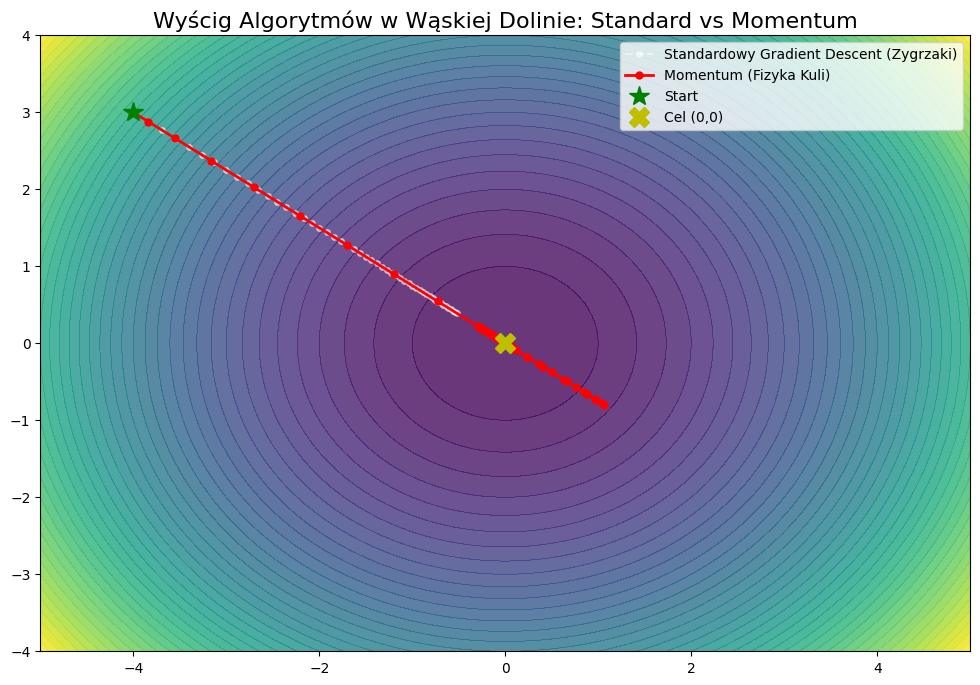

In [4]:
def gradient_descent_momentum(start_x, start_y, learning_rate, epochs, gamma=0.9):
    """
    Wykonuje algorytm optymalizacji Spadku Gradientowego z wykorzystaniem Momentum (pędu).

    Parametry (Co funkcja przyjmuje):
    ---------------------------------
    start_x       : float - Początkowa współrzędna X punktu startowego (gdzie zrzucamy kulkę).
    start_y       : float - Początkowa współrzędna Y punktu startowego.
    learning_rate : float - Współczynnik uczenia (alfa). Określa siłę, z jaką gradient wpływa na zmianę prędkości.
    epochs        : int   - Liczba iteracji (epok). Ile kroków algorytm ma wykonać przed zatrzymaniem.
    gamma         : float - Współczynnik zachowania pędu (Momentum). Wartość od 0.0 do 1.0.
                            - 0.0 oznacza zwykły spadek gradientowy (brak pędu).
                            - 0.9 oznacza, że w danym kroku zachowujemy 90% prędkości z poprzedniego kroku.

    Zwraca (Co funkcja wyrzuca na końcu):
    -------------------------------------
    history_x : list - Lista zawierająca wszystkie historyczne pozycje X (od startu do mety).
    history_y : list - Lista zawierająca wszystkie historyczne pozycje Y.
                       (Zwracamy je, abyśmy mogli narysować na końcu czerwoną ścieżkę na mapie poziomic).
    """

    x, y = start_x, start_y
    history_x, history_y = [x], [y]

    # Inicjalizacja prędkości początkowej (kula na początku stoi w miejscu)
    v_x = 0.0
    v_y = 0.0

    for _ in range(epochs):
        # Wyliczamy wektor gradientu w aktualnej pozycji
        grad = gradient(x, y)

        # 1. Aktualizacja prędkości (ZASADA MOMENTUM)
        # Prędkość = (poprzednia prędkość * gamma) + (kierunek spadku * learning_rate)
        v_x = gamma * v_x + learning_rate * grad[0]
        v_y = gamma * v_y + learning_rate * grad[1]

        # 2. Aktualizacja pozycji
        # Ponieważ gradient i prędkość kierują nas W DÓŁ (do minimum), odejmujemy wektor prędkości.
        x = x - v_x
        y = y - v_y

        # Zapisujemy nową pozycję do naszej historii
        history_x.append(x)
        history_y.append(y)

    return history_x, history_y


# --- PRZEPROWADZENIE WYŚCIGU (STANDARD vs MOMENTUM) ---

start_point = (-4.0, 3.0)
lr = 0.02
kroki = 50

# Zawodnik 1: Klasyczny Spadek Gradientowy (używamy funkcji napisanej wczesniej)
hx1, hy1, _ = gradient_descent(start_point[0], start_point[1], lr, kroki)

# Zawodnik 2: Spadek Gradientowy z Momentum
hx2, hy2 = gradient_descent_momentum(start_point[0], start_point[1], lr, kroki, gamma=0.85)

# --- WIZUALIZACJA ---
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

plt.figure(figsize=(12, 8))
plt.contourf(X, Y, Z, levels=40, cmap='viridis', alpha=0.8)

# Rysujemy obie trasy
plt.plot(hx1, hy1, 'w--o', markersize=4, label='Standardowy Gradient Descent (Zygrzaki)', alpha=0.5)
plt.plot(hx2, hy2, 'r-o', markersize=5, linewidth=2, label='Momentum (Fizyka Kuli)')

plt.plot(start_point[0], start_point[1], 'g*', markersize=15, label='Start')
plt.plot(0, 0, 'yX', markersize=15, label='Cel (0,0)')

plt.title('Wyścig Algorytmów w Wąskiej Dolinie: Standard vs Momentum', fontsize=16)
plt.legend()
plt.show()

# ZADANIE DLA EKSPERTÓW: Ucieczka z pułapki (Stochastyczny Szum)

Krajobrazy błędów współczesnych sieci neuronowych (np. ChatGPT) wcale nie przypominają gładkich, idealnych dolin. Są to potwornie skomplikowane powierzchnie pełne kraterów, górek i fałszywych dolin (tzw. **minimów lokalnych**).

Standardowy Spadek Gradientowy ma jedną fatalną wadę: jest **chciwy**. Zawsze idzie tam, gdzie jest najbardziej stromo w dół. Jeśli zrzucisz go na krajobraz przypominający "wytłaczankę do jajek", natychmiast wpadnie do najbliższego małego dołka. Ponieważ na dnie dołka gradient wynosi zero (jest płasko), algorytm pomyśli: *"Udało się, jestem na samym dole świata!"* i zatrzyma się, ignorując fakt, że prawdziwe dno znajduje się kilka kraterów dalej.

### Rozwiązanie AI: Szum i Stochastyczność (SGD)
Aby temu zapobiec, inżynierowie celowo "psują" wyliczony gradient, dodając do niego losowy szum (symulując tym samym trenowanie na małych, losowych paczkach danych - stąd nazwa *Stochastic Gradient Descent*). Ten szum działa jak trzęsienie ziemi, które potrafi wyrzucić kulkę z płytkiego dołka, pozwalając jej kontynuować podróż w dół.

### Twoje ostateczne wyzwanie:
1. Zdefiniowaliśmy dla Ciebie nową, niezwykle złośliwą funkcję przypominającą wytłaczankę do jajek (bazującą na słynnej funkcji Rastrigina).
2. Napisz nową pętlę `noisy_gradient_descent`.
3. Przed pomnożeniem gradientu przez `learning_rate`, dodaj do wektora gradientu losowy szum wygenerowany z rozkładu normalnego (Gaussa): `np.random.normal(0, noise_strength, 2)`.
4. Porównaj na jednym wykresie, jak standardowy model utyka w pierwszym dołku, a model "zaszumiony" przebija się do centrum!

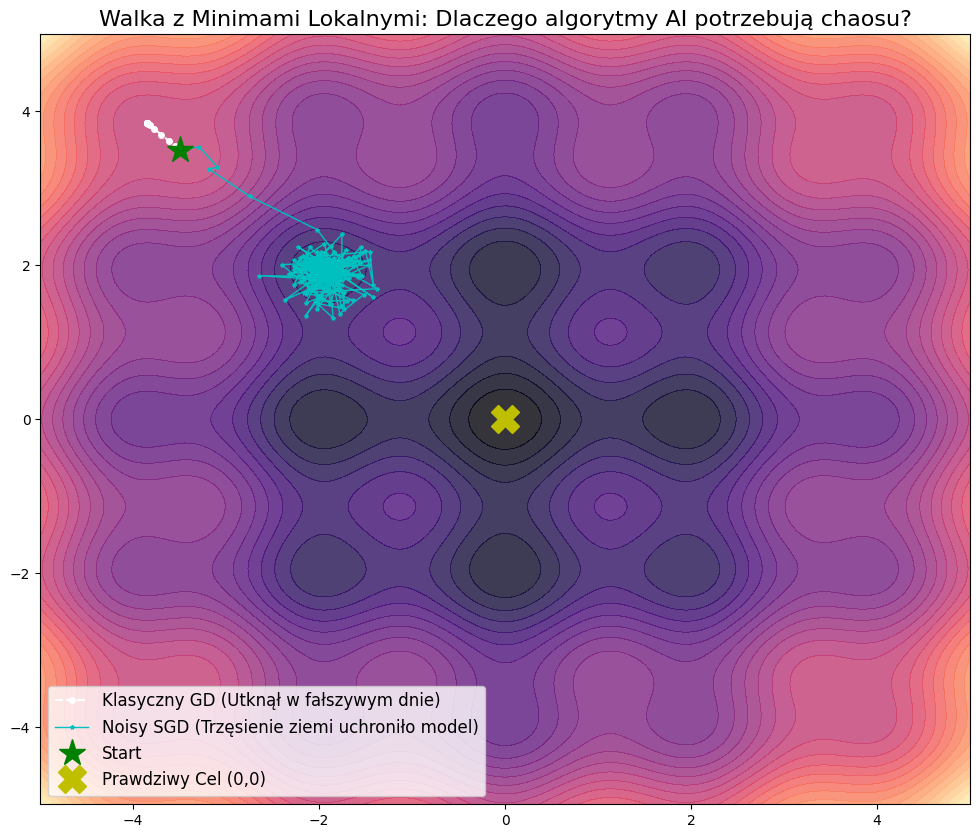

In [5]:
# =====================================================================
# ZADANIE DLA EKSPERTÓW: STOCHASTYCZNY SPADEK GRADIENTOWEGO (Wersja uzupełniona)
# =====================================================================

# 1. Zdefiniowanie złośliwego krajobrazu (Misa z mnóstwem pułapek)
def f_bumpy(x, y):
    # Składnik miski + składnik oscylujący (kratery)
    return (x**2 + y**2) - 3 * np.cos(3 * x) - 3 * np.cos(3 * y)

def grad_bumpy(x, y):
    # Wyliczone pochodne cząstkowe (tylko pierwszego rzędu!)
    df_dx = 2 * x + 9 * np.sin(3 * x)
    df_dy = 2 * y + 9 * np.sin(3 * y)
    return np.array([df_dx, df_dy])


# 2. Implementacja zaszumionego optymalizatora
def noisy_gradient_descent(start_x, start_y, learning_rate, epochs, noise_strength):
    """
    Wykonuje algorytm Stochastycznego Spadku Gradientowego (SGD) z celowo dodanym szumem.
    Szum działa jak "trzęsienie ziemi", pomagając modelowi wyskoczyć z minimów lokalnych
    (pułapek) i kontynuować poszukiwania globalnego dna.

    Parametry (Co funkcja przyjmuje):
    ---------------------------------
    start_x        : float - Początkowa współrzędna X punktu startowego (zrzutu kulki).
    start_y        : float - Początkowa współrzędna Y punktu startowego.
    learning_rate  : float - Współczynnik uczenia (alfa). Określa, jak duży krok robimy w kierunku gradientu.
    epochs         : int   - Liczba iteracji (epok). Ile kroków algorytm ma wykonać na mapie.
    noise_strength : float - Siła wstrzykiwanego szumu (odchylenie standardowe rozkładu normalnego).
                             - Wartość 0.0 oznacza klasyczny spadek gradientowy (brak szumu).
                             - Większe wartości generują mocniejsze "kopnięcia", które pozwalają
                               wyskoczyć z głębszych kraterów, ale mogą też utrudnić ostateczne
                               osiadanie na samym dnie.

    Zwraca (Co funkcja wyrzuca na końcu):
    -------------------------------------
    history_x : list - Lista wszystkich historycznych współrzędnych X trasy algorytmu.
    history_y : list - Lista wszystkich historycznych współrzędnych Y trasy algorytmu.
                       (Niezbędne do późniejszego narysowania wykresu ścieżki).
    """
    x, y = start_x, start_y
    history_x, history_y = [x], [y]

    for _ in range(epochs):
        # Wyliczamy idealny, matematyczny gradient
        grad = grad_bumpy(x, y)

        # ZADANIE: Dodajemy trzęsienie ziemi (szum) do naszych pochodnych!
        # Generujemy 2 losowe liczby z rozkładu normalnego (dla osi X i Y)
        szum = np.random.normal(loc=0.0, scale=noise_strength, size=2)

        # "Psujemy" nasz gradient dodając do niego szum
        zepsuty_grad = grad + szum

        # Wykonujemy krok na podstawie zepsutego gradientu
        x = x - learning_rate * zepsuty_grad[0]
        y = y - learning_rate * zepsuty_grad[1]

        history_x.append(x)
        history_y.append(y)

    return history_x, history_y


# --- WIELKI TEST ---
start_pt = (-3.5, 3.5)
lr = 0.05
kroki = 150

# Zawodnik 1: Klasyczny algorytm (ślepo ufa pochodnym)
hx_gd, hy_gd, _ = gradient_descent(start_pt[0], start_pt[1], lr, kroki) # UWAGA: ta funkcja wywoła stare f(x,y).
# Musimy chwilowo podmienić funkcje w Pythonie lub napisać dla niego dedykowane wywołanie:
hx_gd, hy_gd = [start_pt[0]], [start_pt[1]]
x_temp, y_temp = start_pt
for _ in range(kroki):
    g = grad_bumpy(x_temp, y_temp)
    x_temp -= lr * g[0]
    y_temp -= lr * g[1]
    hx_gd.append(x_temp)
    hy_gd.append(y_temp)

# Zawodnik 2: Zaszumiony algorytm (Stochastic Gradient Descent)
# Ustawiamy siłę szumu np. na 4.0 - wystarczająco dużo, by wybić z małego dołka
hx_noise, hy_noise = noisy_gradient_descent(start_pt[0], start_pt[1], lr, kroki, noise_strength=4.0)


# --- OSTATECZNA WIZUALIZACJA ---
x_range = np.linspace(-5, 5, 200) # Zwiększona rozdzielczość dla ładnych kraterów
y_range = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f_bumpy(X, Y)

plt.figure(figsize=(12, 10))
# Rysujemy mapę poziomic - zobaczysz na niej mnóstwo pułapek!
plt.contourf(X, Y, Z, levels=30, cmap='magma', alpha=0.8)

# Wykresy tras
plt.plot(hx_gd, hy_gd, 'w--o', markersize=4, label='Klasyczny GD (Utknął w fałszywym dnie)')
plt.plot(hx_noise, hy_noise, 'c-*', markersize=3, linewidth=1, label='Noisy SGD (Trzęsienie ziemi uchroniło model)')

plt.plot(start_pt[0], start_pt[1], 'g*', markersize=20, label='Start')
plt.plot(0, 0, 'yX', markersize=20, label='Prawdziwy Cel (0,0)')

plt.title('Walka z Minimami Lokalnymi: Dlaczego algorytmy AI potrzebują chaosu?', fontsize=16)
plt.legend(loc='lower left', fontsize=12)
plt.show()